|          | 2           | 3           | 4           |
|----------|-------------|-------------|-------------|
| **(a)**  | 2/9 = 0.222 | 3/9 = 0.333 | 4/9 = 0.444 |
| **total** (2+3+4)=9|             |             |             |
| **(b)**  | 4/29 = 0.138 | 9/29 = 0.310 | 16/29 = 0.552 |
| **total** (4+9+16)=29|              |              |               |
| **(c)**  | 8/58 = 0.138 | 18/58 = 0.310 | 32/58 = 0.552 |
| **total** (8+18+32)=58|              |               |               |
| **(d)**  | 24/89 = 0.270 | 29/89 = 0.326 | 36/89 = 0.404 |
| **total** (24+29+36)=89|               |               |               |


 f1(x) = |x|
x   fitness   probability
2     2       0.222
3     3       0.333
4     4       0.444

 f2(x) = x^2
x   fitness   probability
2     4       0.138
3     9       0.310
4     16       0.552

 f3(x) = 2x^2
x   fitness   probability
2     8       0.138
3     18       0.310
4     32       0.552

 f4(x) = x^2 + 20
x   fitness   probability
2     24       0.270
3     29       0.326
4     36       0.404


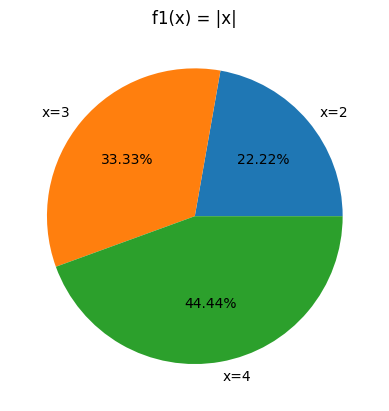

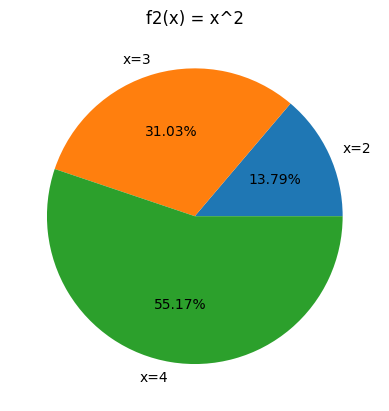

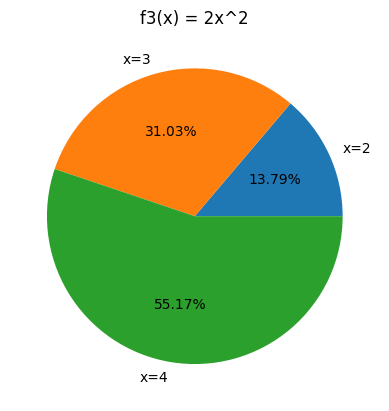

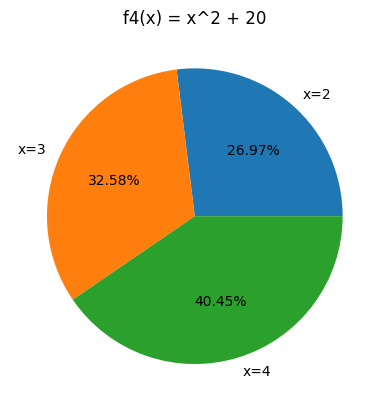

In [26]:
import matplotlib.pyplot as plt

# Individuals
x = [2, 3, 4]

# Fitness functions
fitness_functions = {
    "f1(x) = |x|": [abs(i) for i in x],
    "f2(x) = x^2": [i**2 for i in x],
    "f3(x) = 2x^2": [2*(i**2) for i in x],
    "f4(x) = x^2 + 20": [i**2 + 20 for i in x]
}

for name, fitness in fitness_functions.items():

    total = sum(fitness)

    # Compute probabilities
    probabilities = [f/total for f in fitness]

    print("\n", name)
    print("x   fitness   probability")

    for xi, fi, pi in zip(x, fitness, probabilities):
        print(f"{xi}     {fi}       {pi:.3f}")

    # Plot roulette wheel
    plt.figure()
    plt.pie(probabilities, labels=[f"x={i}" for i in x], autopct='%1.2f%%')
    plt.title(name)

plt.show()

Regarding the pie charts, we can conclude that fitness scaling does affect the selection process, depending on the operation applied.
- Exponentiating x in the fitness function increases the differences between individuals, making the selection more biased toward the fittest.

- Multiplying the fitness by a constant does not change the selection pressure.

- Adding a constant to the fitness decreases the differences between individuals, reducing selection pressure and giving lower-fitness individuals a higher chance of being selected.

PART B2

In [4]:
import numpy as np
import random
import time

coords = np.loadtxt("file-tsp.txt")

print(coords.shape)

# -----------------------------
# Distance matrix
# -----------------------------
def distance_matrix(coords):
    n = len(coords)
    dist = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            dist[i,j] = np.linalg.norm(coords[i]-coords[j])
    return dist

# -----------------------------
# Tour length
# -----------------------------
def tour_length(tour, dist):
    return sum(dist[tour[i], tour[(i+1)%len(tour)]] for i in range(len(tour)))

# -----------------------------
# Mutation (swap)
# -----------------------------
def mutate(tour):
    i,j = random.sample(range(len(tour)),2)
    tour[i], tour[j] = tour[j], tour[i]

# -----------------------------
# Ordered crossover
# -----------------------------
def crossover(p1,p2):
    n=len(p1)
    a,b = sorted(random.sample(range(n),2))
    child=[None]*n
    child[a:b]=p1[a:b]

    ptr=0
    for x in p2:
        if x not in child:
            while child[ptr] is not None:
                ptr+=1
            child[ptr]=x
    return child

# -----------------------------
# Tournament selection
# -----------------------------
def tournament(pop, dist, k=5):
    candidates = random.sample(pop, k)
    p1 = min(candidates, key=lambda x: tour_length(x, dist))
    candidates.remove(p1)
    return p1, min(candidates, key=lambda x: tour_length(x, dist))

# -----------------------------
# 2-opt local search
# -----------------------------
def two_opt(tour, dist):

    best = tour
    improved = True

    while improved:
        improved = False
        for i in range(1,len(tour)-2):
            for j in range(i+1,len(tour)):
                if j-i==1:
                    continue

                new = best[:]
                new[i:j] = best[j-1:i-1:-1]

                if tour_length(new,dist) < tour_length(best,dist):
                    best = new
                    improved = True
        tour = best

    return best

(50, 2)


In [5]:
def EA(coords, pop_size=100, generations=500):

    dist = distance_matrix(coords)
    n = len(coords)

    pop = [random.sample(range(n),n) for _ in range(pop_size)]

    for g in range(generations):

        pop = sorted(pop, key=lambda x: tour_length(x,dist))

        new_pop = pop[:10]  # elitism

        while len(new_pop) < pop_size:

            p1,p2 = tournament(pop, dist)
            child = crossover(p1,p2)

            if random.random()<0.2:
                mutate(child)

            new_pop.append(child)

        pop = new_pop

    best = min(pop, key=lambda x: tour_length(x,dist))
    return tour_length(best,dist)

In [4]:
def MA(coords, pop_size=100, generations=500):

    dist = distance_matrix(coords)
    n=len(coords)

    pop=[random.sample(range(n),n) for _ in range(pop_size)]

    for g in range(generations):

        pop = sorted(pop, key=lambda x: tour_length(x,dist))

        new_pop = pop[:10]

        while len(new_pop) < pop_size:

            p1,p2 = random.sample(pop[:50],2)
            child = crossover(p1,p2)

            if random.random()<0.2:
                mutate(child)

            # local search
            child = two_opt(child,dist)

            new_pop.append(child)

        pop = new_pop

    best = min(pop, key=lambda x: tour_length(x,dist))
    return tour_length(best,dist)

In [8]:
ea = EA(coords)

ma = MA(coords)

print(ea)
print(ma)

135.60207054994686
119.94240011114012


In [9]:
berlin = np.loadtxt("berlin52.txt")

print(berlin.shape)

ea = EA(berlin)

ma = MA(berlin)

print(ea)
print(ma)

(52, 2)
9887.490231771919
7544.365901904086


In [17]:
import numpy as np
import random

def EA(coords,
       pop_size=100,
       generations=500,
       mutation_rate=0.2,
       elitism=10):

    dist = distance_matrix(coords)
    n = len(coords)

    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    best_history = []

    for g in range(generations):

        pop = sorted(pop, key=lambda x: tour_length(x, dist))
        best_history.append(tour_length(pop[0], dist))

        new_pop = pop[:elitism]

        while len(new_pop) < pop_size:

            p1, p2 = tournament(pop, dist)

            child = crossover(p1, p2)

            if random.random() < mutation_rate:
                mutate(child)

            new_pop.append(child)

        pop = new_pop

    return best_history

In [18]:
def MA(coords, pop_size=100, generations=500):

    dist = distance_matrix(coords)
    n = len(coords)

    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    best_history = []

    for g in range(generations):

        pop = sorted(pop, key=lambda x: tour_length(x, dist))

        best_history.append(tour_length(pop[0], dist))

        new_pop = pop[:10]

        while len(new_pop) < pop_size:

            p1, p2 = random.sample(pop[:50], 2)
            child = crossover(p1, p2)

            if random.random() < 0.2:
                mutate(child)

            child = two_opt(child, dist)

            new_pop.append(child)

        pop = new_pop

    return best_history

In [19]:
runs = 5

ea_runs_tsp = []
ma_runs_tsp = []

#for r in range(runs):
 #   ea_runs_tsp.append(EA(coords,mutation_rate=0.2,
  #                   elitism=5))
   # ma_runs_tsp.append(MA(coords))


mutation_rates = [0.05, 0.1, 0.2, 0.3]
elitism_values = [0, 5, 10, 20]

results = {}

for e in elitism_values:
    results[e] = []

    for m in mutation_rates:
        runs = []

        for _ in range(10):  
            best = EA(coords,
                      mutation_rate=m,
                      elitism=e)
            runs.append(best)

        mean = np.mean(runs)
        std = np.std(runs)

        results[e].append((mean, std))

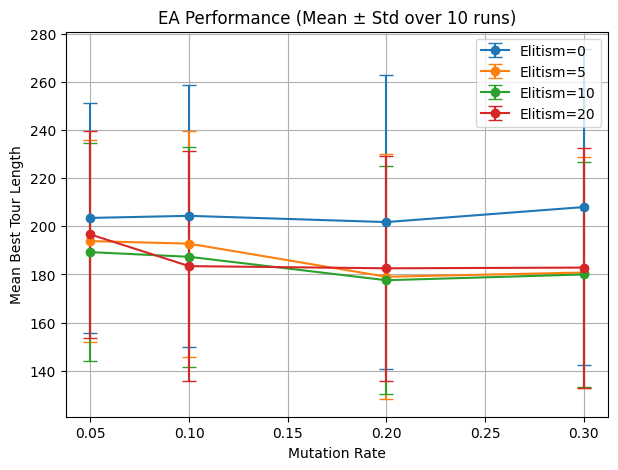

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for e in elitism_values:
    means = [r[0] for r in results[e]]
    stds  = [r[1] for r in results[e]]

    plt.errorbar(mutation_rates, means, yerr=stds,
                 marker='o', capsize=5, label=f'Elitism={e}')

plt.xlabel("Mutation Rate")
plt.ylabel("Mean Best Tour Length")
plt.title("EA Performance (Mean ± Std over 10 runs)")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
print(results)

{0: [(np.float64(203.51017666622857), np.float64(47.7086029196725)), (np.float64(204.3820881515179), np.float64(54.486800223604085)), (np.float64(201.78405154706493), np.float64(61.258632656743174)), (np.float64(208.02033352454637), np.float64(65.62758248768054))], 5: [(np.float64(193.87688160835546), np.float64(42.083782019996406)), (np.float64(192.81672523734406), np.float64(46.95446259717978)), (np.float64(179.0457150765636), np.float64(50.911270007362674)), (np.float64(180.81463920905134), np.float64(48.067836962913205))], 10: [(np.float64(189.2908794468291), np.float64(45.428702986507226)), (np.float64(187.3464112416108), np.float64(45.80389980731434)), (np.float64(177.6058180948663), np.float64(47.380340527942636)), (np.float64(180.00666169938722), np.float64(46.93084535078703))], 20: [(np.float64(196.63574961817775), np.float64(43.20082856519921)), (np.float64(183.47114077086545), np.float64(47.951053379124176)), (np.float64(182.5628835719576), np.float64(46.668613433268995)), (

In [21]:
ea_runs = np.array(ea_runs_tsp)
ma_runs = np.array(ma_runs_tsp)

ea_mean = ea_runs.mean(axis=0)
ma_mean = ma_runs.mean(axis=0)

/var/folders/st/kw4469cs0w93k2f7tb8268ww0000gn/T/ipykernel_35131/2523759578.py:4: RuntimeWarning: Mean of empty slice
  ea_mean = ea_runs.mean(axis=0)
/Users/nunosilva/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/st/kw4469cs0w93k2f7tb8268ww0000gn/T/ipykernel_35131/2523759578.py:5: RuntimeWarning: Mean of empty slice
  ma_mean = ma_runs.mean(axis=0)


In [22]:
import matplotlib.pyplot as plt

generations = range(len(ea_mean))

plt.figure(figsize=(8,5))

plt.plot(generations, ea_mean, label="EA")
plt.plot(generations, ma_mean, label="Memetic Algorithm")

plt.xlabel("Generation")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA Convergence on TSP")

plt.legend()
plt.grid(True)

plt.show()

TypeError: object of type 'numpy.float64' has no len()

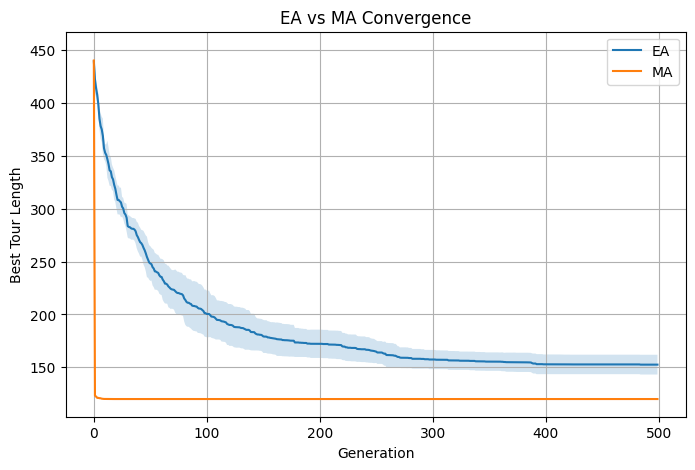

In [ ]:
ea_std = ea_runs.std(axis=0)
ma_std = ma_runs.std(axis=0)

plt.figure(figsize=(8,5))

plt.plot(generations, ea_mean, label="EA")
plt.fill_between(generations, ea_mean-ea_std, ea_mean+ea_std, alpha=0.2)

plt.plot(generations, ma_mean, label="MA")
plt.fill_between(generations, ma_mean-ma_std, ma_mean+ma_std, alpha=0.2)

plt.xlabel("Generation")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA Convergence")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
runs = 5

ea_runs_berlin = []
ma_runs_berlin = []

for r in range(runs):
    ea_runs_berlin.append(EA(coords))
    ma_runs_berlin.append(MA(coords))

In [ ]:
ea_runs = np.array(ea_runs_berlin)
ma_runs = np.array(ma_runs_berlin)

ea_mean = ea_runs.mean(axis=0)
ma_mean = ma_runs.mean(axis=0)

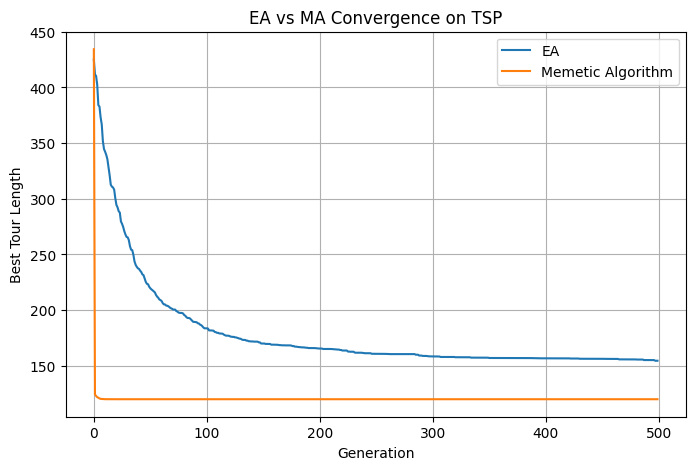

In [ ]:
generations = range(len(ea_mean))

plt.figure(figsize=(8,5))

plt.plot(generations, ea_mean, label="EA")
plt.plot(generations, ma_mean, label="Memetic Algorithm")

plt.xlabel("Generation")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA Convergence on TSP")

plt.legend()
plt.grid(True)

plt.show()

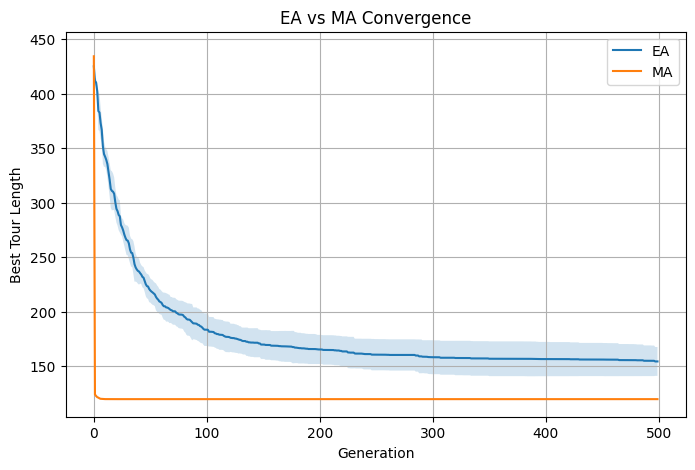

In [ ]:
ea_std = ea_runs.std(axis=0)
ma_std = ma_runs.std(axis=0)

plt.figure(figsize=(8,5))

plt.plot(generations, ea_mean, label="EA")
plt.fill_between(generations, ea_mean-ea_std, ea_mean+ea_std, alpha=0.2)

plt.plot(generations, ma_mean, label="MA")
plt.fill_between(generations, ma_mean-ma_std, ma_mean+ma_std, alpha=0.2)

plt.xlabel("Generation")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA Convergence")

plt.legend()
plt.grid(True)

plt.show()

In [6]:
def EA_runtime(coords, time_limit=60):

    dist = distance_matrix(coords)
    n = len(coords)

    pop_size = 100
    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    start = time.time()

    best_history = []
    time_history = []

    while time.time() - start < time_limit:

        pop = sorted(pop, key=lambda x: tour_length(x, dist))
        best = tour_length(pop[0], dist)

        best_history.append(best)
        time_history.append(time.time() - start)

        new_pop = pop[:10]

        while len(new_pop) < pop_size:

            p1, p2 = tournament(pop, dist)
            child = crossover(p1, p2)

            if random.random() < 0.2:
                mutate(child)

            new_pop.append(child)

        pop = new_pop

    return time_history, best_history

In [7]:
def MA_runtime(coords, time_limit=60):

    dist = distance_matrix(coords)
    n = len(coords)

    pop_size = 100
    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    start = time.time()

    best_history = []
    time_history = []

    while time.time() - start < time_limit:

        pop = sorted(pop, key=lambda x: tour_length(x, dist))
        best = tour_length(pop[0], dist)

        best_history.append(best)
        time_history.append(time.time() - start)

        new_pop = pop[:10]

        while len(new_pop) < pop_size:

            p1, p2 = random.sample(pop[:50], 2)
            child = crossover(p1, p2)

            if random.random() < 0.2:
                mutate(child)

            # local search
            child = two_opt(child, dist)

            new_pop.append(child)

        pop = new_pop

    return time_history, best_history

In [ ]:
runs = 5

ea_curves = []
ma_curves = []

for i in range(runs):
    t_ea, b_ea = EA_runtime(coords, 60)
    t_ma, b_ma = MA_runtime(coords, 60)

    ea_curves.append((t_ea, b_ea))
    ma_curves.append((t_ma, b_ma))

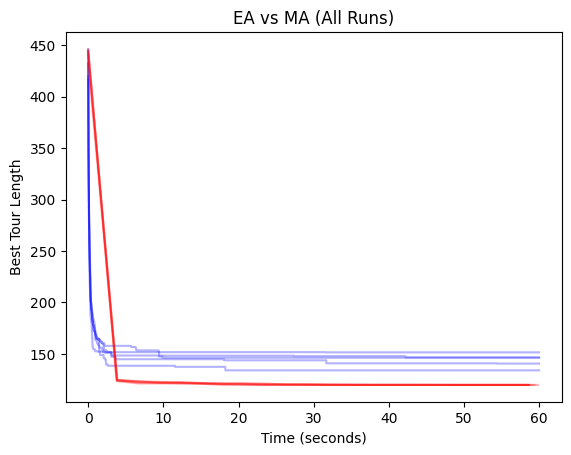

In [ ]:
import matplotlib.pyplot as plt

ea_mean = ea_curves[1].mean(axis=0)
ma_mean = ma_curves[1].mean(axis=0)

ea_std = ea_curves[1].std(axis=0)
ma_std = ma_curves[1].std(axis=0)

for t, b in ea_curves:
    plt.plot(t, ea_mean, label="EA")
    plt.fill_between(t, ea_mean-ea_std, ea_mean+ea_std, alpha=0.2)

for t, b in ma_curves:
    plt.plot(t, ma_mean, label="MA")
    plt.fill_between(t, ma_mean-ma_std, ma_mean+ma_std, alpha=0.2)

plt.xlabel("Time (seconds)")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA (All Runs)")
plt.show()


In [ ]:
def EA_evaluations(coords, max_evals=100000):

    dist = distance_matrix(coords)
    n = len(coords)

    pop_size = 100
    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    evals = 0

    best_history = []
    eval_history = []

    while evals < max_evals:

        pop = sorted(pop, key=lambda x: tour_length(x, dist))
        best = tour_length(pop[0], dist)

        best_history.append(best)
        eval_history.append(evals)

        new_pop = pop[:10]

        while len(new_pop) < pop_size and evals < max_evals:

            p1, p2 = tournament(pop, dist)
            child = crossover(p1, p2)

            if random.random() < 0.2:
                mutate(child)

            tour_length(child, dist)
            evals += 1

            new_pop.append(child)

        pop = new_pop

    return eval_history, best_history

In [ ]:
def MA_evaluations(coords, max_evals=100000):

    dist = distance_matrix(coords)
    n = len(coords)

    pop_size = 100
    pop = [random.sample(range(n), n) for _ in range(pop_size)]

    evals = 0

    best_history = []
    eval_history = []

    while evals < max_evals:

        pop = sorted(pop, key=lambda x: tour_length(x, dist))
        best = tour_length(pop[0], dist)

        best_history.append(best)
        eval_history.append(evals)

        new_pop = pop[:10]

        while len(new_pop) < pop_size and evals < max_evals:

            p1, p2 = random.sample(pop[:50], 2)
            child = crossover(p1, p2)

            if random.random() < 0.2:
                mutate(child)

            # evaluate
            tour_length(child, dist)
            evals += 1

            # local search
            child = two_opt(child, dist)

            new_pop.append(child)

        pop = new_pop

    return eval_history, best_history

In [ ]:
runs = 5

ea_results = []
ma_results = []

for i in range(runs):

    e_ea, b_ea = EA_evaluations(coords)
    e_ma, b_ma = MA_evaluations(coords)

    ea_results.append((e_ea, b_ea))
    ma_results.append((e_ma, b_ma))


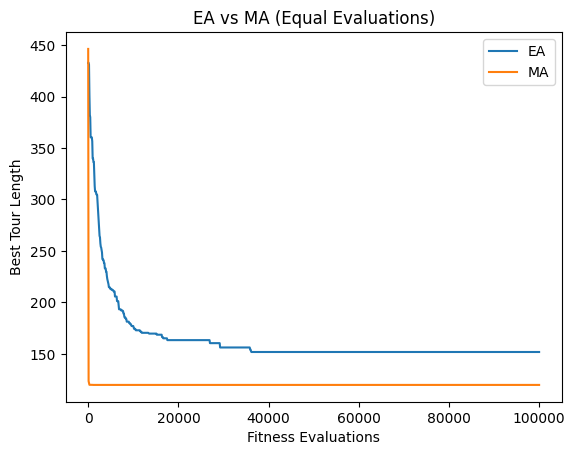

In [ ]:
plt.plot(e_ea, b_ea, label="EA")
plt.plot(e_ma, b_ma, label="MA")

plt.xlabel("Fitness Evaluations")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA (Equal Evaluations)")

plt.legend()
plt.show()



ea_mean = ea_results[1].mean(axis=0)
ma_mean = ma_results[1].mean(axis=0)

ea_std = ea_results[1].std(axis=0)
ma_std = ma_results[1].std(axis=0)

for t, b in ea_results:
    plt.plot(t, ea_mean, label="EA")
    plt.fill_between(t, ea_mean-ea_std, ea_mean+ea_std, alpha=0.2)

for t, b in ma_results:
    plt.plot(t, ma_mean, label="MA")
    plt.fill_between(t, ma_mean-ma_std, ma_mean+ma_std, alpha=0.2)

plt.xlabel("Fitness Evaluations")
plt.ylabel("Best Tour Length")
plt.title("EA vs MA (Equal Evaluations)")
plt.show()